In [9]:
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [10]:
def parse_waypoints(wp_str):
    """Parse waypoint strings, extract x and y coordinates, and flatten."""
    list_str = f"[{wp_str}]"
    try:
        waypoints = ast.literal_eval(list_str)
        # Extract (x, y) coordinates
        xy_only = [[wp[0], wp[1]] for wp in waypoints]
        return np.array(xy_only).flatten() # Flatten to a 24-dimensional vector
    except Exception as e:
        print(f"Error parsing waypoints: {e}")
        return None

In [11]:
def run_kmeans_for_bucket(X, n_clusters, bucket_name):
    """Run K-Means clustering for data in a single bucket."""
    if len(X) == 0:
        print(f"Warning: Bucket [{bucket_name}] is empty.")
        return np.empty((0, X.shape[1]))
        
    if len(X) < n_clusters:
        print(f"Warning: Data in [{bucket_name}] ({len(X)}) is less than requested clusters ({n_clusters}).")
        n_clusters = len(X)
        
    print(f"Running K-Means clustering for [{bucket_name}] bucket (extracting {n_clusters} anchors)...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans.fit(X)
    return kmeans.cluster_centers_

In [12]:
def plot_background_samples(ax, X_data, color, max_samples=5000):
    """Plot semi-transparent background of original trajectories."""
    if len(X_data) == 0: 
        return
    
    # Shuffle and sample to prevent memory overflow and an overly dark plot
    np.random.shuffle(X_data)
    sample_size = min(len(X_data), max_samples)
    samples = X_data[:sample_size].reshape(-1, 12, 2)
    
    for traj in samples:
        ax.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.08, linewidth=1.0, zorder=1)

In [16]:
jsonl_file_path = 'nuscenes_reasons_Qwen_32B.jsonl'

output_filename = 'nusc_traj_dict_128.npy'

LATERAL_THRESHOLD = 4.0  # Lateral threshold in meters

# Allocation of 128 anchor slots
N_LEFT = 2
N_RIGHT = 2
N_STRAIGHT = 2

left_bucket, right_bucket, straight_bucket = [], [], []

print("1. Scanning data and bucketing...")
try:
    with open(jsonl_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip(): 
                continue
            
            data = json.loads(line)
            wp_str = data.get("wp_future", "")
            
            if wp_str:
                flat_traj = parse_waypoints(wp_str)
                if flat_traj is not None and len(flat_traj) == 24:
                    # Get the Y coordinate of the last point (index 23)
                    last_y = flat_traj[23]
                    
                    # Bucketing logic based on the lateral threshold
                    if last_y > LATERAL_THRESHOLD:
                        left_bucket.append(flat_traj)
                    elif last_y < -LATERAL_THRESHOLD:
                        right_bucket.append(flat_traj)
                    else:
                        straight_bucket.append(flat_traj)
except FileNotFoundError:
    print(f"Error: File '{jsonl_file_path}' not found. Please check the path.")
    
X_left = np.array(left_bucket)
X_right = np.array(right_bucket)
X_straight = np.array(straight_bucket)

total = len(X_left) + len(X_right) + len(X_straight)
if total == 0:
    print("No valid data found!")
    
print("-" * 50)
print(f"Data Distribution (Total: {total} trajectories):")
print(f"  Left bucket:     {len(X_left)} ({(len(X_left)/total)*100:.1f}%)")
print(f"  Straight bucket: {len(X_straight)} ({(len(X_straight)/total)*100:.1f}%)")
print(f"  Right bucket:    {len(X_right)} ({(len(X_right)/total)*100:.1f}%)")
print("-" * 50)

1. Scanning data and bucketing...
--------------------------------------------------
Data Distribution (Total: 16548 trajectories):
  Left bucket:     1569 (9.5%)
  Straight bucket: 13116 (79.3%)
  Right bucket:    1863 (11.3%)
--------------------------------------------------


In [17]:
# 2. Run K-Means for each bucket
centers_left = run_kmeans_for_bucket(X_left, N_LEFT, "Left")
centers_right = run_kmeans_for_bucket(X_right, N_RIGHT, "Right")
centers_straight = run_kmeans_for_bucket(X_straight, N_STRAIGHT, "Straight")

# Stack all cluster centers to form the complete set of anchors (shape: 128, 24)
print("\n2. Stacking and saving anchor trajectories...")
all_centers = np.vstack((centers_left, centers_right, centers_straight))

# Reshape back to trajectory format (128, 12, 2)
anchor_trajectories = all_centers.reshape(-1, 12, 2)

# Save to .npy file (Crucial step for downstream VLM training)
np.save(output_filename, anchor_trajectories)
print(f"[Success] Saved {anchor_trajectories.shape[0]} anchors to '{output_filename}'")

# Reshape individual bucket centers for plotting with different colors
anchors_left = centers_left.reshape(-1, 12, 2)
anchors_right = centers_right.reshape(-1, 12, 2)
anchors_straight = centers_straight.reshape(-1, 12, 2)

Running K-Means clustering for [Left] bucket (extracting 2 anchors)...
Running K-Means clustering for [Right] bucket (extracting 2 anchors)...
Running K-Means clustering for [Straight] bucket (extracting 2 anchors)...

2. Stacking and saving anchor trajectories...
[Success] Saved 6 anchors to 'nusc_traj_dict_128.npy'



3. Plotting the comparison chart...
Plotting complete! Displaying image...


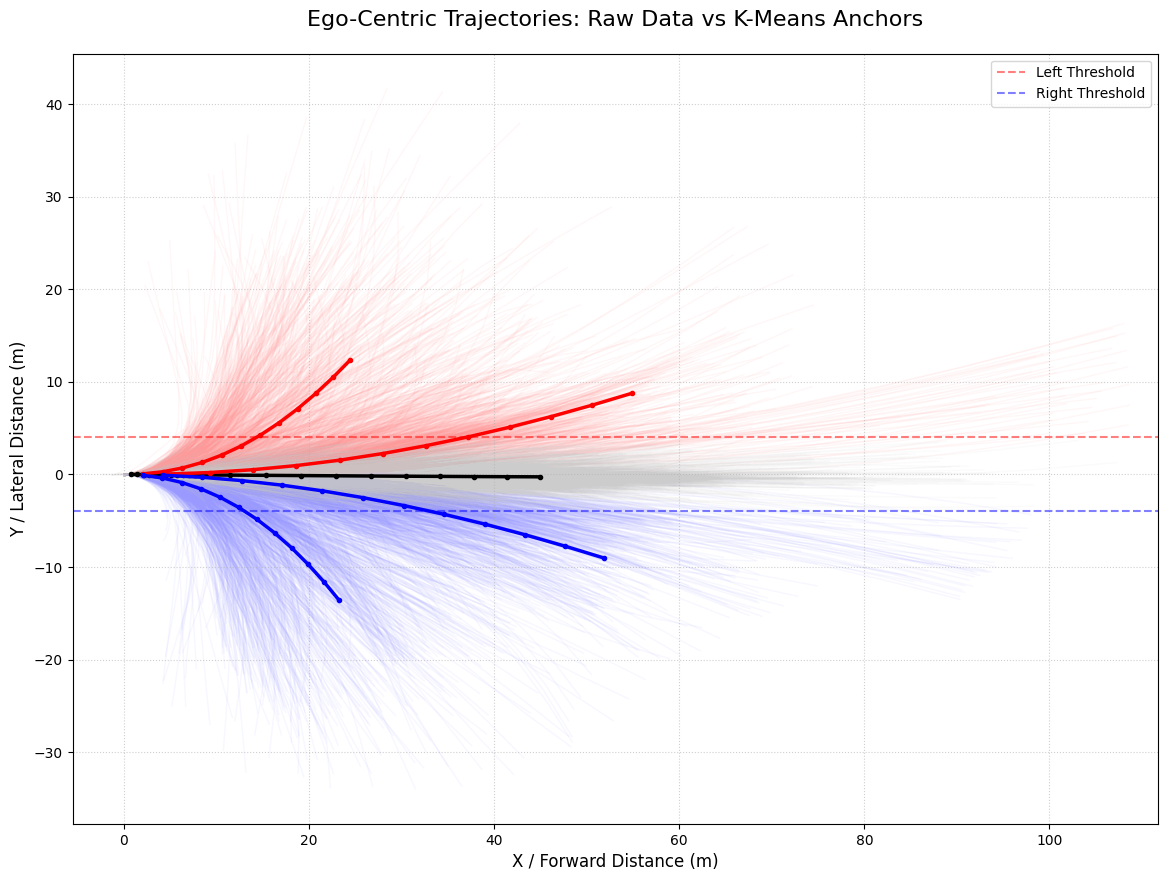

In [18]:
# 3. Plotting
print("\n3. Plotting the comparison chart...")
fig, ax = plt.subplots(figsize=(14, 10))

# Plot semi-transparent background data
plot_background_samples(ax, X_left.copy(), color='#ff9999')      # Light Red
plot_background_samples(ax, X_right.copy(), color='#9999ff')     # Light Blue
plot_background_samples(ax, X_straight.copy(), color='#cccccc')  # Light Gray

# Plot K-Means anchors on top
for traj in anchors_left:
    ax.plot(traj[:, 0], traj[:, 1], color='red', linewidth=2.5, zorder=5, marker='o', markersize=3)
for traj in anchors_right:
    ax.plot(traj[:, 0], traj[:, 1], color='blue', linewidth=2.5, zorder=5, marker='o', markersize=3)
for traj in anchors_straight:
    ax.plot(traj[:, 0], traj[:, 1], color='black', linewidth=2.5, zorder=4, marker='o', markersize=3)

# Draw lateral threshold reference lines
ax.axhline(y=LATERAL_THRESHOLD, color='r', linestyle='--', alpha=0.5, label='Left Threshold')
ax.axhline(y=-LATERAL_THRESHOLD, color='b', linestyle='--', alpha=0.5, label='Right Threshold')

# Chart styling
plt.title("Ego-Centric Trajectories: Raw Data vs K-Means Anchors", fontsize=16, pad=20)
plt.xlabel("X / Forward Distance (m)", fontsize=12)
plt.ylabel("Y / Lateral Distance (m)", fontsize=12)
plt.legend()

plt.axis('equal') 
plt.grid(True, linestyle=':', alpha=0.6)

print("Plotting complete! Displaying image...")
plt.show()